# TODO:
- add the possibility to continue the training of a model even after it has been already trained once
- rewrite the decoder so that the input is not a subsample or a sum of the dt in each block but that it takes all of the noise in the timeseries of dt

In [1]:
from juliacall import Main as jl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

jl.include("SolarDynamo.jl")
jl.seval("using .SolarDynamo")
sn = jl.SolarDynamo.sn
sn_from_noise = jl.SolarDynamo.sn_from_noise

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


---
# Global settings

In [2]:
TOBS = 200 # how many time steps to simulate
TWARMUP = 200 # time steps that are discarded

# prior range for parameters
PRIORS = {
    "tau": (0.1, 10), # years
    "T": (0.1, 15), # years
    "Nd": (10, 15),
    "sigma": (0, 0.3),
    "Bmax": (5, 5)
}
PARAM_NAMES = list(PRIORS.keys())

---
# Simulator

In [17]:
def simulate(theta, seed=None, noise_handling="sum"):
    """
    noise_handling:
    - subsample
    - sum
    """
    dt = 0.1
    tau, T, Nd, sigma, Bmax = theta
    T = round(T / dt) * dt
    
    if seed is not None:
        np.random.seed(seed)
    
    # generate noise
    Ndt = int( (TWARMUP+TOBS) / dt ) # = 4000 if TWARMUP=200,TOBS=200,dt=0.1
    eps_dt = np.random.randn(Ndt).astype(np.float64)
    
    # convert to julia types
    theta_jl = jl.Vector[jl.Float64]([tau, T, Nd, sigma, Bmax])
    eps_jl = jl.Vector[jl.Float64](eps_dt)
    
    # stochastic simulation
    x = sn_from_noise(theta_jl, eps_jl, Twarmup=TWARMUP, Tobs=TOBS, dt=dt)
    
    # convert back to python
    x = np.array(x, dtype=np.float32)
    
    # extract from eps_dt just the non-warmup portion
    warmup_steps = int(TWARMUP / dt)
    k = int(1.0/dt)
    if noise_handling=="subsample":
        # take every k-th step from the post-warmup portion
        eps_obs = eps_dt[warmup_steps::k]
    elif noise_handling=="sum":
        # instead of subsampling, compute the sum of noise per block
        eps_obs = np.array([np.sum(eps_dt[warmup_steps + i*k : warmup_steps + (i+1)*k]) for i in range(TOBS)])
        eps_obs = eps_obs / np.sqrt(k)
    
    eps_obs = eps_obs[:TOBS].astype(np.float32)

    return x, eps_obs

# Dataset generator

In [4]:
def generate_dataset(n_samples, fixed, stats=None, loss="MSE", noise_handling="sum"):
    varying_names = [k for k,v in fixed.items() if v is None]
    n_params = len(varying_names)
    
    # create the dataset
    X = np.zeros((n_samples,TOBS), dtype=np.float32)
    Noise = np.zeros((n_samples,TOBS), dtype=np.float32)
    Params = np.zeros((n_samples,n_params), dtype=np.float32)

    for i in range(n_samples):
        theta = {}
        for name,(low,high) in PRIORS.items():
            if fixed[name] is not None:
                theta[name] = fixed[name]
            else:
                theta[name] = np.random.uniform(low,high)
                
        x, noise = simulate([theta[k] for k in PARAM_NAMES], noise_handling=noise_handling)

        X[i] = x
        Noise[i] = noise
        Params[i] = [theta[k] for k in varying_names]

        if (i+1)%50 == 0:
            print(f"Generated {i+1}/{n_samples} samples", end="\r")
    
    print()
    
    # normalize the dataset if no stats is given
    if stats is None:
        # normalize x based on loss
        x_mean = X.mean() if loss=="MSE" else 0
        x_std = X.std() if loss=="MSE" else 1
        
        # don't normalize noise because already normalized
        n_mean = 0
        n_std = 1
        
        # normalize parameters
        p_mean = Params.mean(axis=0)
        p_std  = Params.std(axis=0)
        p_std[p_std == 0] = 1.0
        
        stats = {
            "x_mean": x_mean, "x_std": x_std,
            "n_mean": n_mean, "n_std": n_std,
            "p_mean": p_mean, "p_std": p_std
        }
    
    X = (X-stats["x_mean"]) / stats["x_std"]
    Noise = (Noise-stats["n_mean"]) / stats["n_std"]
    Params = (Params-stats["p_mean"]) / stats["p_std"]
    
    return X, Noise, Params, stats

# ENCA architecture

In [5]:
class Encoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.net = nn.Sequential(
            # block 1
            nn.Conv1d(1,  16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2), # halve the time dimension
            
            # block 2
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            
            # project to n_summary channels
            nn.Conv1d(32, n_summary, kernel_size=3, padding=1),
        )
        
        # average over time: (batch,n_summary,TOBS)->(batch,n_summary,1)
        self.pool = nn.AdaptiveAvgPool1d(1)
    
    def forward(self, x):
        # x: (batch,TOBS) -> add channel dim -> (batch,1,TOBS)
        x = x.unsqueeze(1)
        # x -> (batch,n_summary,TOBS/2)
        x = self.net(x)
        # x -> (batch,n_summary,1)
        x = self.pool(x)
        # x -> (batch,n_summary)
        x = x.squeeze(-1)
        
        return x


class Decoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(n_summary+1, 32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    
    def forward(self, s, noise):
        # s: (batch,n_summary)
        # noise: (batch,TOBS)
        
        # add the time series as the 2nd dimension for s
        s = s.unsqueeze(1) # (batch,1,n_summary)
        s_tiled = s.expand(-1,TOBS,-1) # (batch,TOBS,n_summary)
        
        # to concatenate noise with s we must convert to 3D
        noise3d = noise.unsqueeze(2) # (batch,TOBS,1)
        
        # concatenate s and noise to get input for decoder
        inp = torch.cat([s_tiled,noise3d], dim=-1) # (batch,TOBS,n_summary+1)
        
        # apply linear layers to last dimension
        x_hat = self.net(inp) # (batch,TOBS,1)
        x_hat = x_hat.squeeze(-1) # (batch,TOBS)
        
        return x_hat


class DecoderBiLSTM(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_summary + 1, hidden_size=16, 
                            num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(32, 1)
    
    def forward(self, s, noise):
        s = s.unsqueeze(1) 
        s_tiled = s.expand(-1, noise.shape[1], -1) 
        noise3d = noise.unsqueeze(2) 
        inp = torch.cat([s_tiled, noise3d], dim=-1) 
        
        lstm_out, _ = self.lstm(inp) 
        x_hat = self.fc(lstm_out).squeeze(-1) 
        
        return x_hat


class ENCA(nn.Module):
    def __init__(self, n_summary, BiLSTM=False):
        super().__init__()
        
        self.encoder = Encoder(n_summary)
        self.decoder = DecoderBiLSTM(n_summary) if BiLSTM else Decoder(n_summary)
    
    def forward(self, x, noise):
        s = self.encoder(x)
        x_hat = self.decoder(s, noise)
        return s, x_hat

In [6]:
class ChiSquare(nn.Module):
    def forward(self, pred, real):
        return ((pred-real)**2 / (real**2 + 1e-6)).mean()

In [29]:
class RelativeErrorLoss(nn.Module):
    def forward(self, pred, real):
        # Use absolute value to handle negative values after normalization
        return ((pred-real)** 2 / (real.abs() + 1e-6)).mean()

# Training

In [32]:
def train(X, Noise, Params, n_summary=None, epochs=100,
          batch_size=64, lr=1e-3, loss="MSE", BiLSTM=False):
    
    n_params = Params.shape[1]
    n_summary = n_summary or n_params+2
    
    # convert to tensors
    Xt = torch.tensor(X)
    Nt = torch.tensor(Noise)
    Pt = torch.tensor(Params)
    
    # create the iterable dataset
    dataset = TensorDataset(Xt,Nt,Pt)
    loader = DataLoader(
        dataset, batch_size=batch_size,
        shuffle=True
    )
    
    # define model, optimizer and loss function
    model = ENCA(n_summary, BiLSTM=BiLSTM)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_func = nn.MSELoss()
    if loss == "Chi Squared":
        loss_func = ChiSquare()
    elif loss == "Relative Error":
        loss_func = RelativeErrorLoss()
    mse = nn.MSELoss()
    
    # loss history
    loss_history = []
    
    model.train()
    for epoch in range(epochs):
        total_loss = [0, 0, 0]
        n_batches = 0
        
        for x_batch, n_batch, p_batch in loader:
            n_batches += 1
            
            # get output from the model
            s, x_hat = model(x_batch, n_batch)
            
            # calculate reconstruction loss and regression loss 
            loss_recon = loss_func(x_hat, x_batch)
            loss_regr = mse(s[:,:n_params], p_batch)
            loss_tot = loss_recon + loss_regr
            
            # backpropagate loss
            optimizer.zero_grad()
            loss_tot.backward()
            optimizer.step()
            
            # save loss
            total_loss[0] += loss_tot.item()
            total_loss[1] += loss_recon.item()
            total_loss[2] += loss_regr.item()
        
        avg_loss = [l/n_batches for l in total_loss]
        loss_history.append(avg_loss)
        
        if (epoch+1)%20 == 0:
            print(f"Epoch {epoch+1:3d}, Loss: {avg_loss[0]:.4f}")
            
    # plot training loss curves
    loss_history = torch.tensor(loss_history)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history[:,0], label="Total loss")
    ax.plot(loss_history[:,1], linestyle="--", label="Reconstruction loss")
    ax.plot(loss_history[:,2], linestyle=":", label="Regression loss")

    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"{loss} Loss")
    ax.set_title("Training Loss Curves")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return model

In [8]:
def evaluate(model, X, Noise, Params, stats, fixed):
    model.eval()
    with torch.no_grad():
        # convert to tensor
        Xt = torch.tensor(X)
        Nt = torch.tensor(Noise)
        
        # prediction
        s,x_hat = model(Xt,Nt)
    
    # convert to numpy
    s = s.numpy()
    x_hat = x_hat.numpy()
    
    # un-noralize paramters to real values
    Params_real = Params*stats["p_std"] + stats["p_mean"]
    varying_names = [k for k,v in fixed.items() if v is None]
    
    # 1) plot reconstruction (3 random examples)
    idx = np.random.choice(len(X), size=3, replace=False)
    fig, axes = plt.subplots(3,1,figsize=(10, 8),sharex=True)
    for ax,i in zip(axes,idx):
        title = ", ".join([f"{p}={Params_real[i,j]:.2f}" for j,p in enumerate(varying_names)])
        
        ax.plot(X[i], label="Original x")
        ax.plot(x_hat[i], label="Reconstructed", ls="--")
        ax.set_title(title)
    
    axes[0].legend()
    axes[-1].set_xlabel("time step")
    plt.suptitle("Reconstruction of data")
    plt.tight_layout()
    plt.show()
    
    # 2) plot s_j vs true param
    n_params = len(varying_names)
    
    fig, axes = plt.subplots(1,n_params,figsize=(4*n_params,4))
    if n_params == 1:
        axes = [axes]
    for i,(ax,name) in enumerate(zip(axes,varying_names)):
        ax.scatter(s[:,i], Params_real[:,i], alpha=0.3, s=8)
        ax.set_ylabel(f"true {name}")
        ax.set_xlabel(f"$s_{i}$")
        ax.set_title(f"$s_{i}$ vs {name}")
    plt.suptitle("Regression check")
    plt.tight_layout()
    plt.show()
    
    # 3) plot latent space
    color_vals = Params_real[:,0] # color by the first varying parameter
    color_name = varying_names[0]
    
    fig, ax = plt.subplots(figsize=(6,5))
    sc = ax.scatter(s[:,0], s[:,1], c=color_vals, 
                    cmap="viridis", alpha=0.4, s=12)
    plt.colorbar(sc, ax=ax, label=color_name)
    ax.set_ylabel("$s_1$")
    ax.set_xlabel("$s_0$")
    plt.suptitle(f"Latent space colored by {color_name}")
    plt.tight_layout()
    plt.show()
    
    return s, x_hat, idx

In [9]:
def run(fixed, model=None, stats=None, n_samples=2000, n_samples_test=1000,
        n_summary=None, epochs=200, batch_size=64, lr=1e-3, loss="MSE", BiLSTM=False,
        noise_handling="sum"):
    
    separator = "\n" + 100 * "-" + 2*"\n"
    res = {}
    
    if model is None and stats is None:
        # generate data
        print(f"\nGenerating training data...")
        X, N, P, stats = generate_dataset(n_samples, fixed=fixed, loss=loss, noise_handling=noise_handling)
        print(f"{separator}Data shape:\n X shape={X.shape}\n Noise={N.shape}\n Parameters={P.shape}")

        # training
        print(f"{separator}Training...")
        model = train(X, N, P, n_summary=n_summary, epochs=epochs,
                      batch_size=batch_size, lr=lr, loss=loss, BiLSTM=BiLSTM)
        
        res["X"] = X
        res["N"] = N
        res["P"] = P
        res["stats"] = stats
        res["model"] = model
    
    # generating test data
    print(f"{separator}Generating test data...")
    X_test, N_test, P_test, _ = generate_dataset(n_samples_test, fixed=fixed, stats=stats)
    
    # evaluating
    print(f"{separator}Evaluating...")
    s, x_hat, idx = evaluate(model, X_test, N_test, P_test, stats, fixed=fixed)
    res["s"] = s
    res["x_hat"] = x_hat
    res["idx"] = idx
    
    return res

---
# 0) Simulation with and without noise

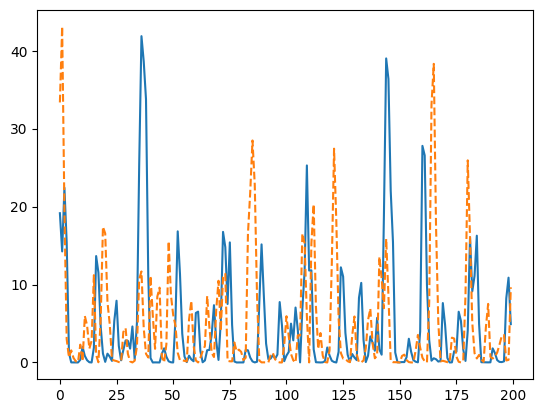

In [10]:
a,_ = simulate([1,5,6,0.1,2], seed=1)
b,_ = simulate([1,5,6,0,2])

plt.plot(a, label="stochastic")
plt.plot(b, label="deterministic", ls="--");

---
# 1) Fixing 4 parameters
## a) MSE loss


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 0.9786
Epoch  40, Loss: 0.9744
Epoch  60, Loss: 0.9689
Epoch  80, Loss: 0.9723
Epoch 100, Loss: 0.9659


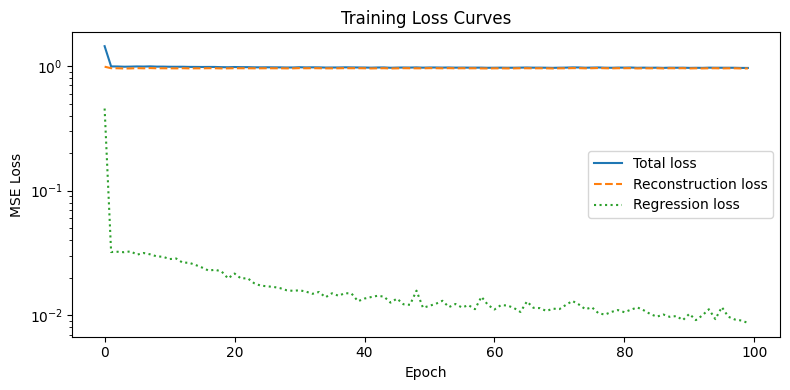


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


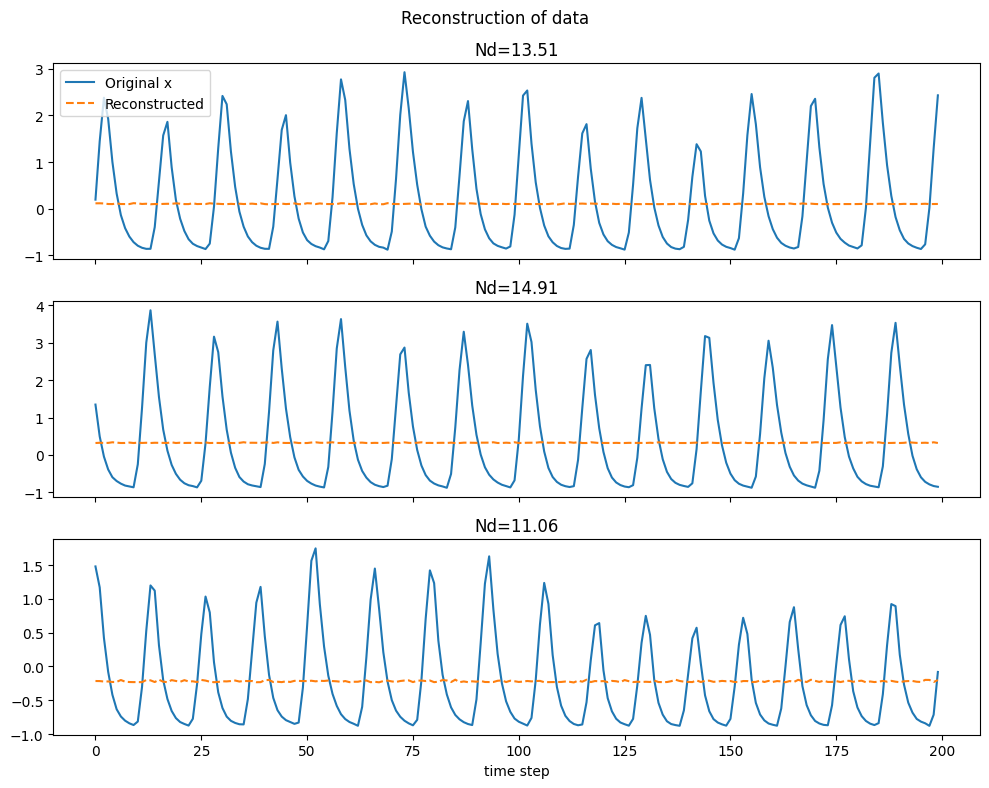

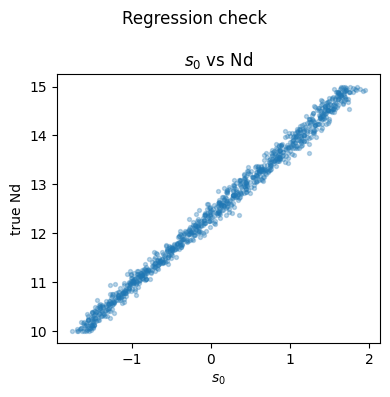

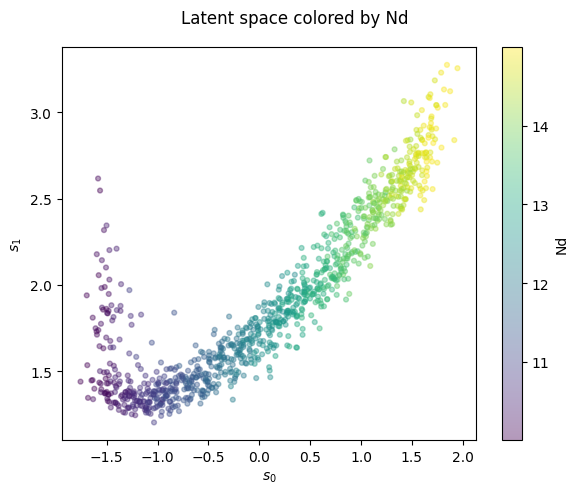

In [24]:
varying_Nd = {
    "tau": 2.8,
    "T": 3.7,
    "Nd": None,
    "sigma": 0.15,
    "Bmax": 5
}

# using MSE loss
res1 = run(varying_Nd, n_samples=5000, epochs=100)

## b) $\chi^2$ loss


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.0332
Epoch  40, Loss: 1.0153
Epoch  60, Loss: 1.0062
Epoch  80, Loss: 1.0101
Epoch 100, Loss: 1.0237


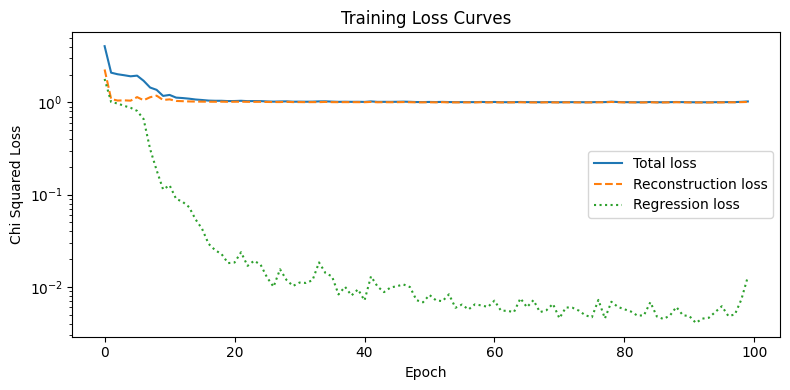


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


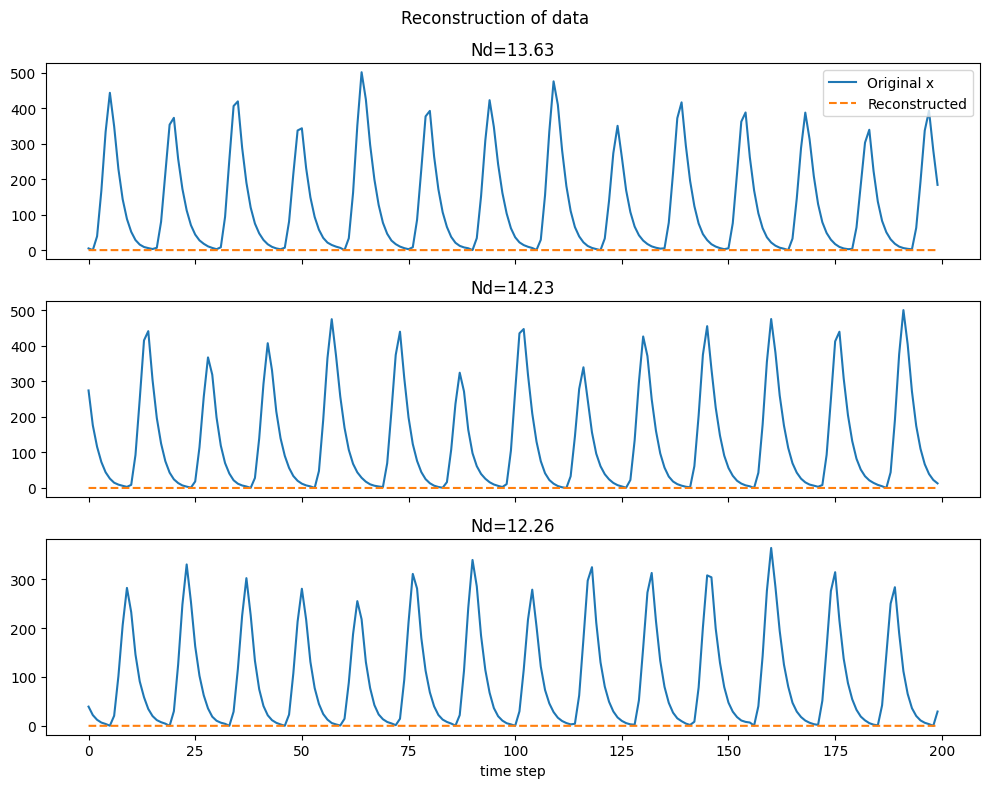

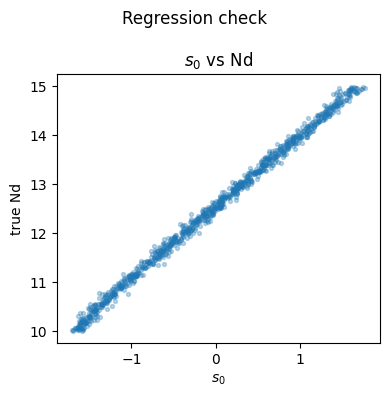

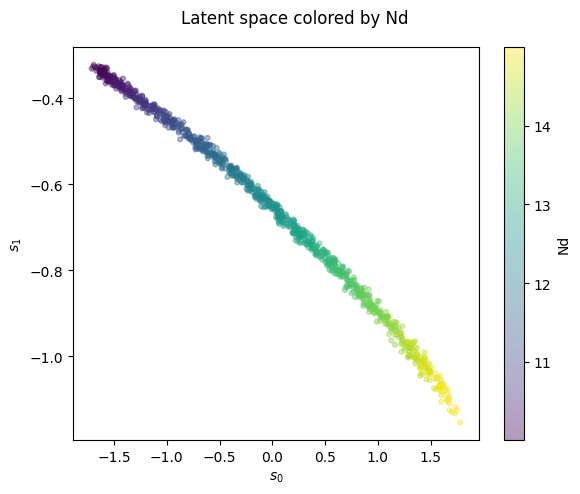

In [25]:
# retrain using chi squared instead of MSE
res1_chi = run(varying_Nd, n_samples=5000, epochs=100, loss="Chi Squared")

## c) BiLSTM Decoder + MSE loss


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 0.9782
Epoch  40, Loss: 0.8385
Epoch  60, Loss: 0.5017
Epoch  80, Loss: 0.4388
Epoch 100, Loss: 0.3916


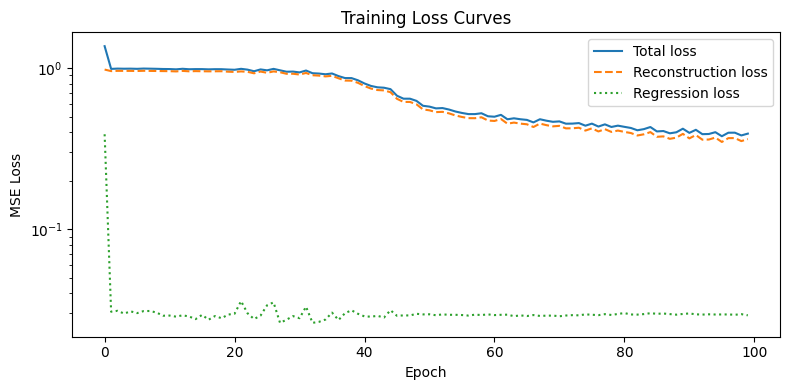


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


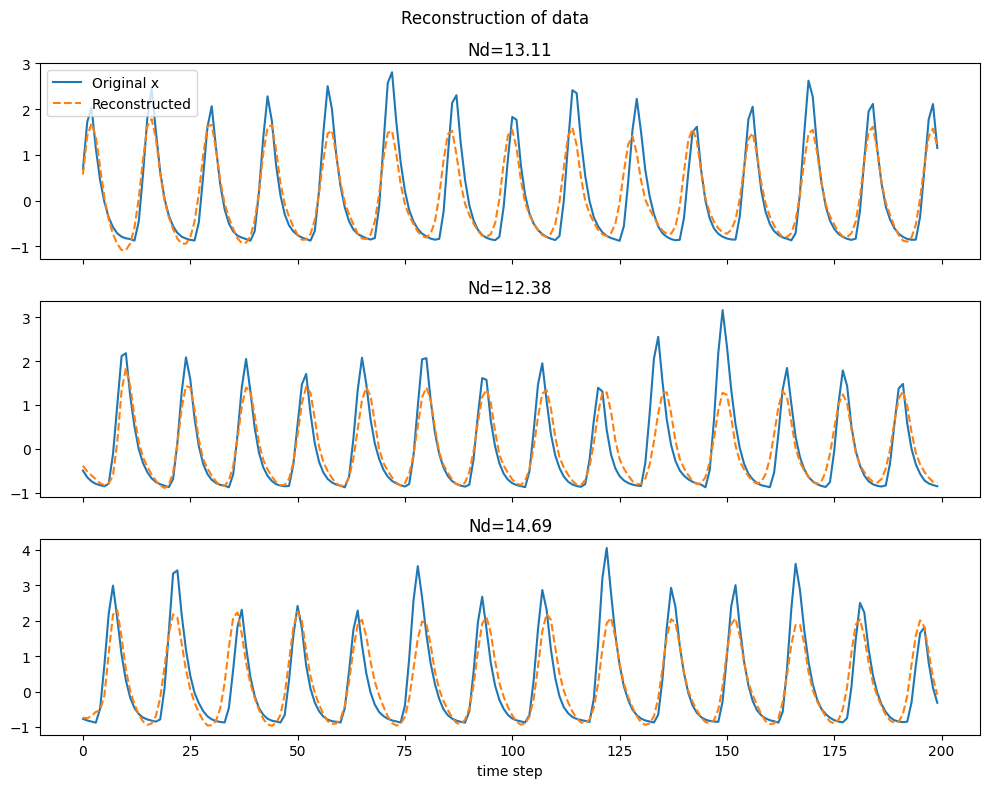

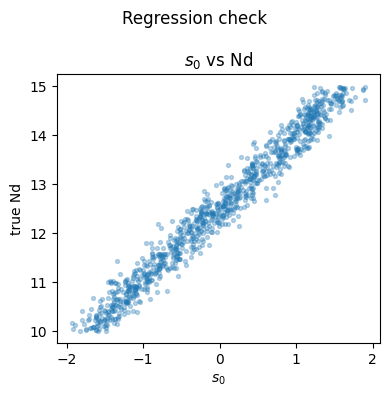

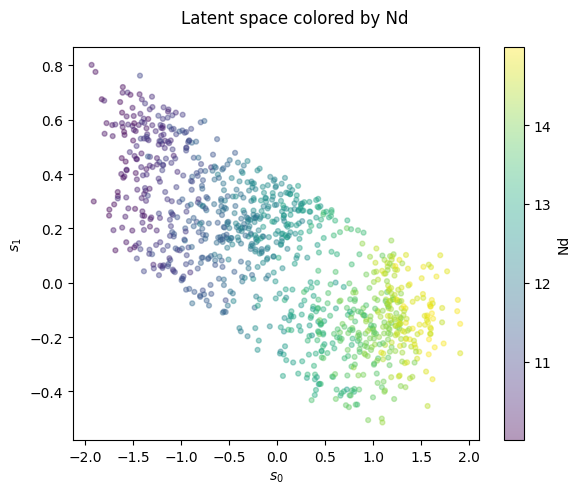

In [26]:
res1d = run(varying_Nd, n_samples=5000, epochs=100, BiLSTM=True)


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 0.9939
Epoch  40, Loss: 0.9822
Epoch  60, Loss: 0.9289
Epoch  80, Loss: 0.5892
Epoch 100, Loss: 0.4879


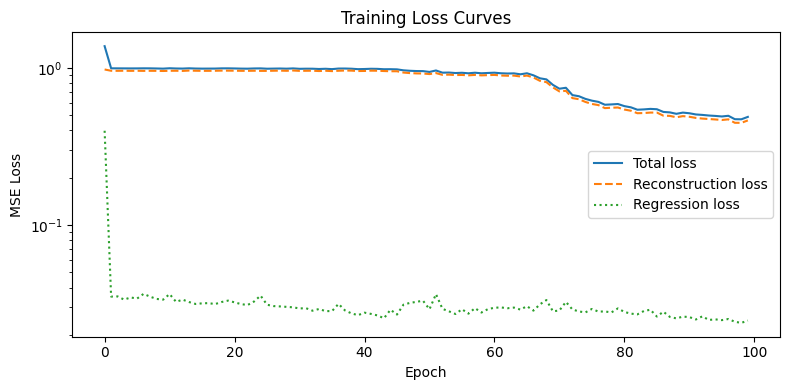


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


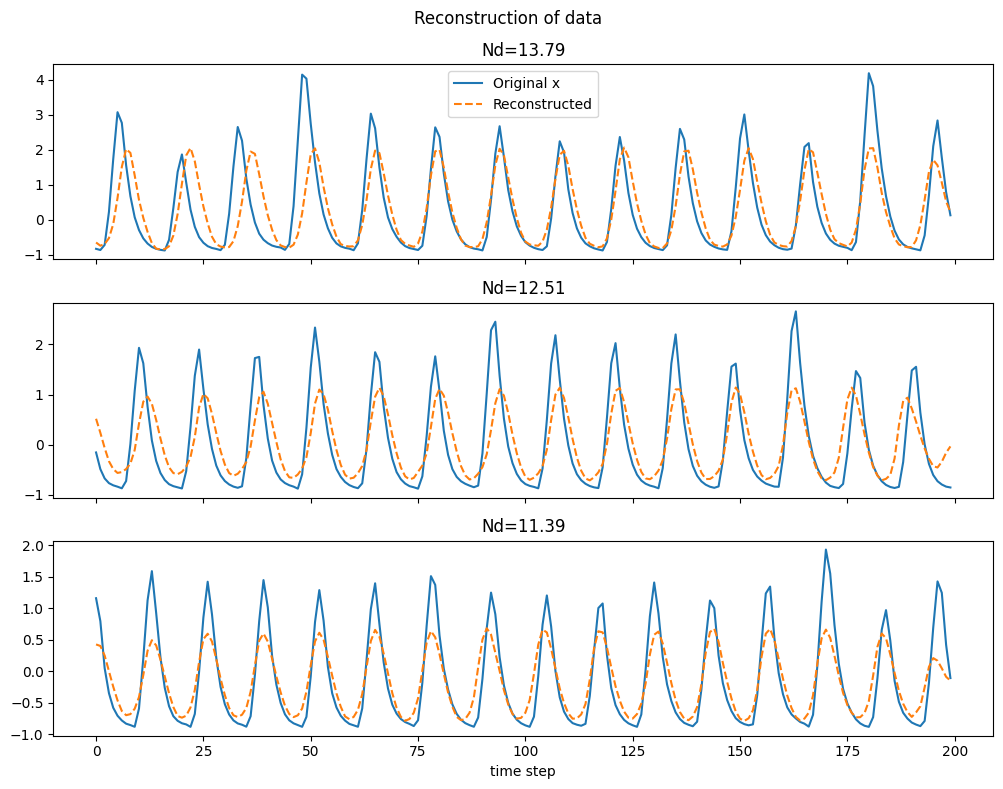

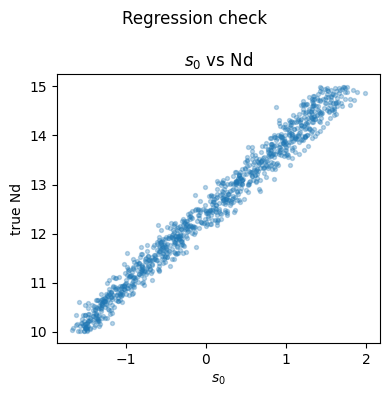

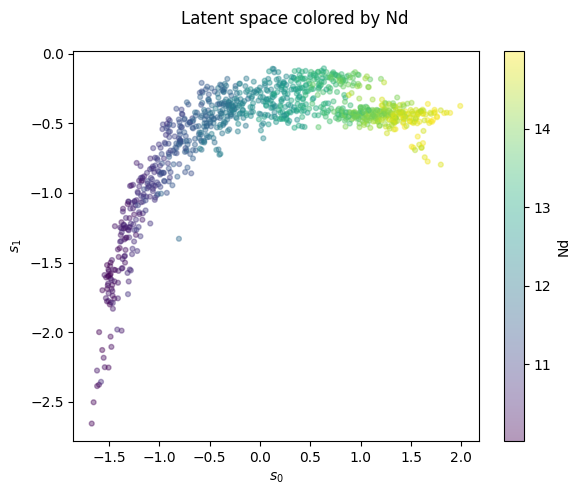

In [16]:
res1d = run(varying_Nd, n_samples=5000, epochs=100, BiLSTM=True, noise_handling="subsample")

## d) BiLSTM Decoder + $\chi^2$


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.0173
Epoch  40, Loss: 1.0073
Epoch  60, Loss: 1.0069
Epoch  80, Loss: 1.0034
Epoch 100, Loss: 1.0013


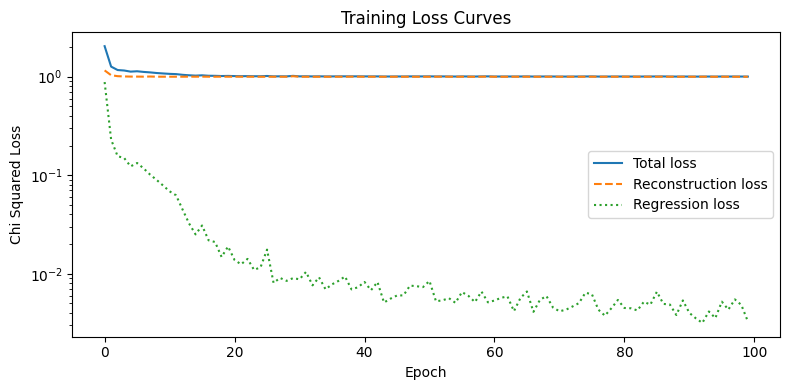


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


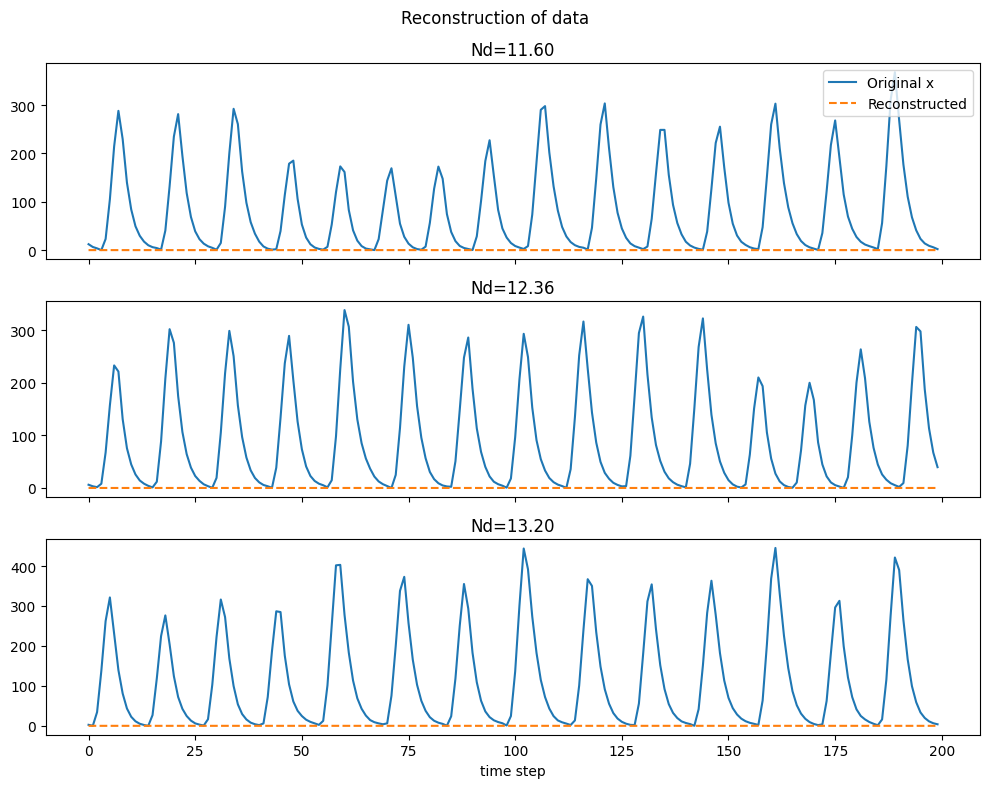

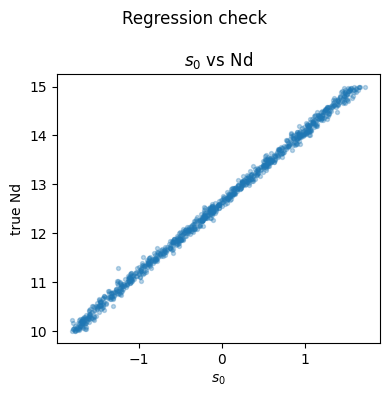

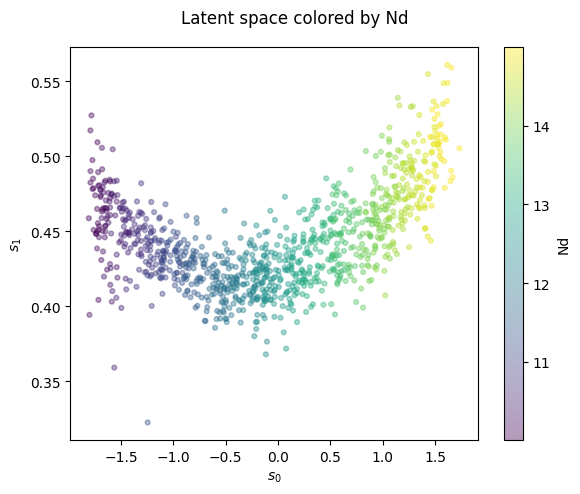

In [27]:
# BiLSTM + Chi Squared
res1e = run(varying_Nd, n_samples=5000, epochs=100, loss="Chi Squared", BiLSTM=True)


Generating training data...
Generated 10000/10000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(10000, 200)
 Noise=(10000, 200)
 Parameters=(10000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.0041
Epoch  40, Loss: 1.0025
Epoch  60, Loss: 1.0015
Epoch  80, Loss: 1.0008
Epoch 100, Loss: 1.0005


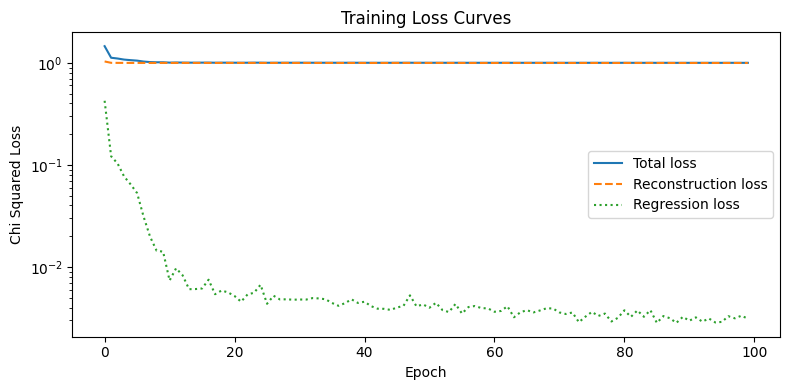


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


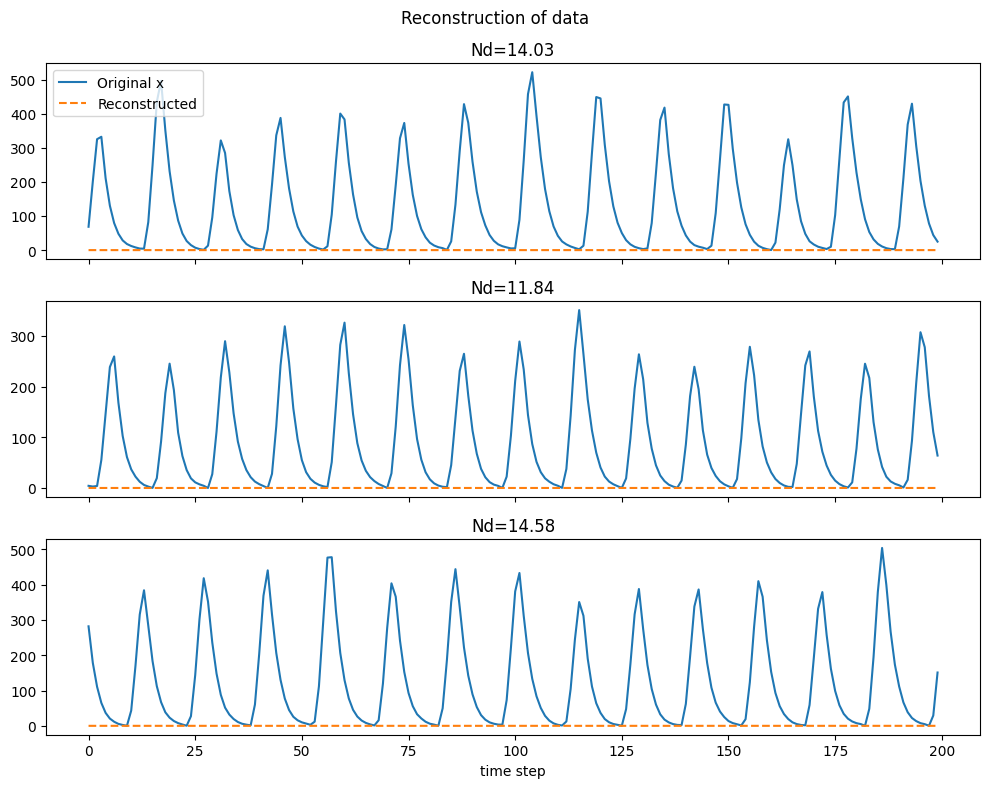

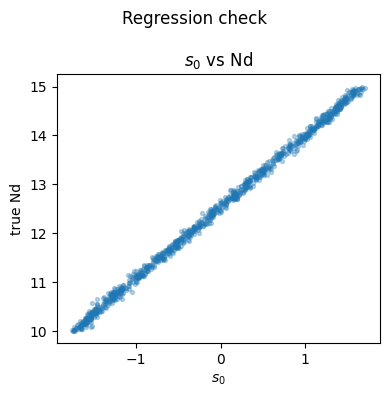

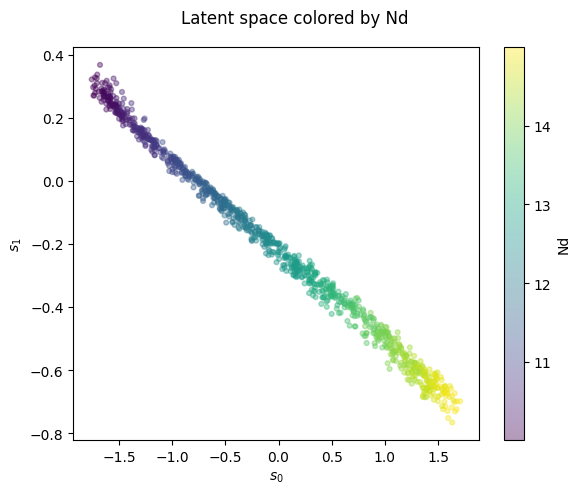

In [28]:
# BiLSTM + Chi Squared
res1e2 = run(varying_Nd, n_samples=10000, epochs=100, loss="Chi Squared", BiLSTM=True)


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 1)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 96.1713
Epoch  40, Loss: 96.0791
Epoch  60, Loss: 96.2024
Epoch  80, Loss: 96.4144
Epoch 100, Loss: 96.0411


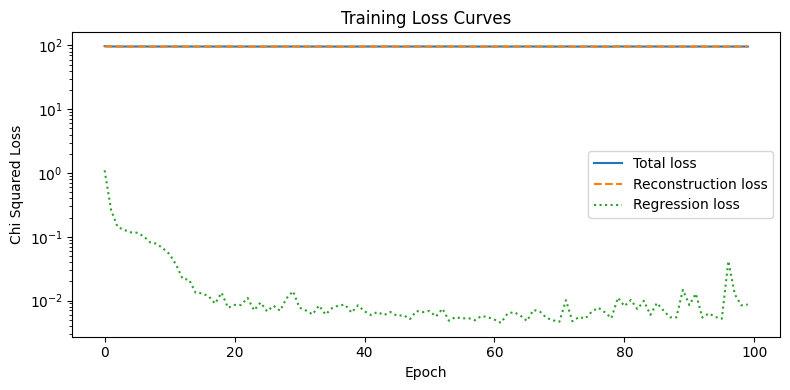


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


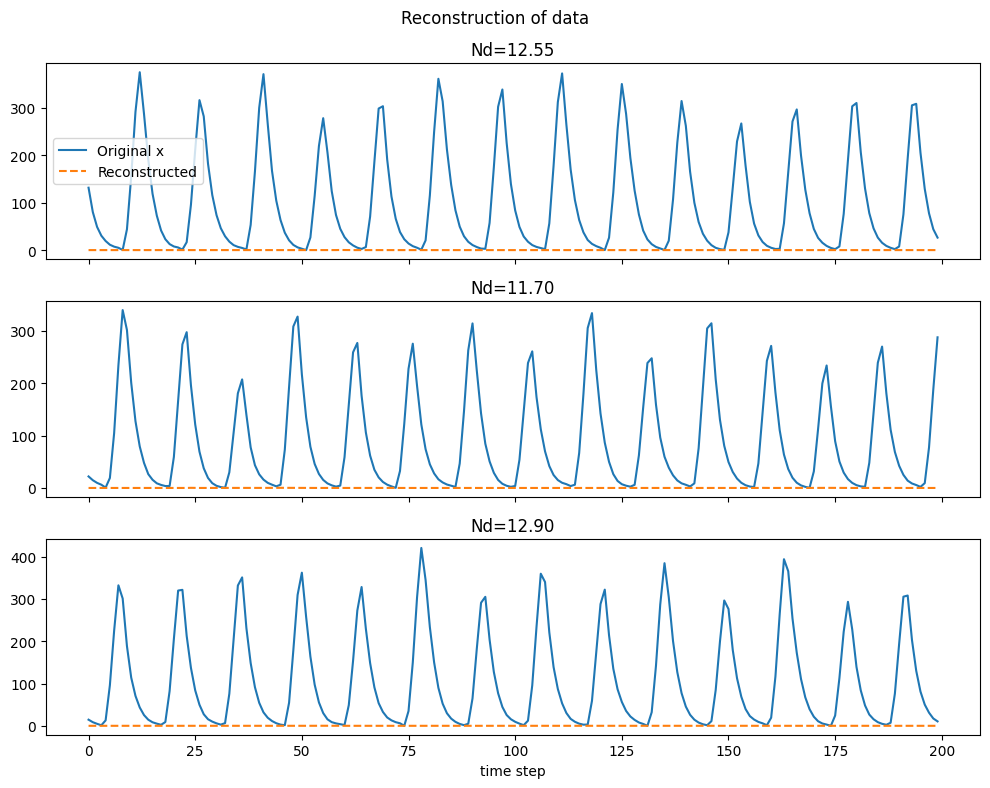

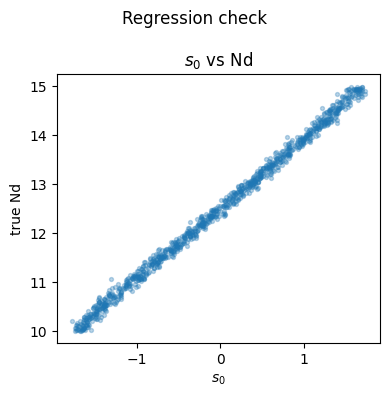

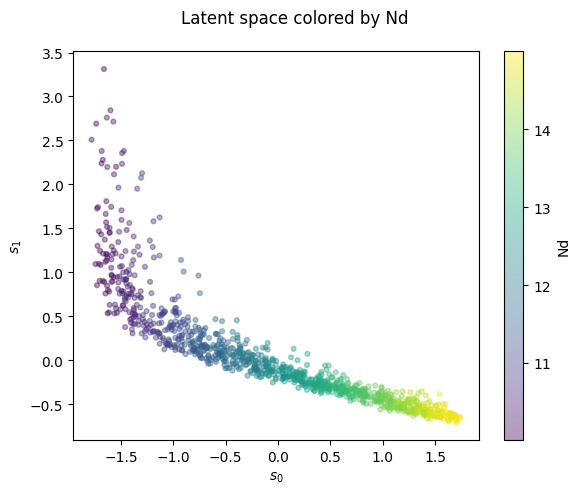

In [31]:
# using Relative Error Loss
res1e3 = run(varying_Nd, n_samples=5000, epochs=100, loss="Relative Error", BiLSTM=True)

---
# 2) Varying all parameters
## a) MSE loss


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 5)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.2639
Epoch  40, Loss: 1.2237
Epoch  60, Loss: 1.2177
Epoch  80, Loss: 1.1949
Epoch 100, Loss: 1.1948


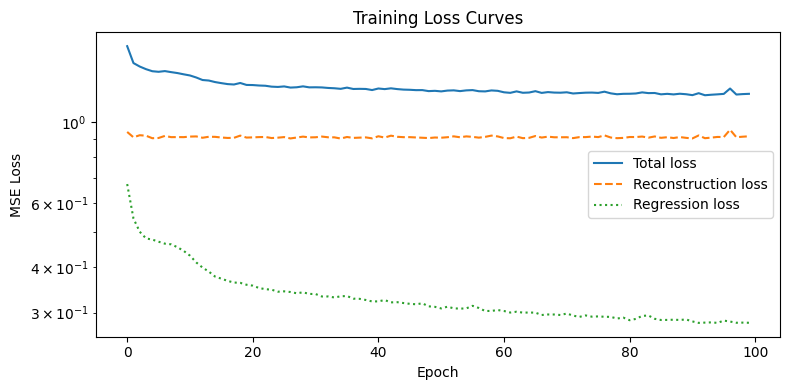


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


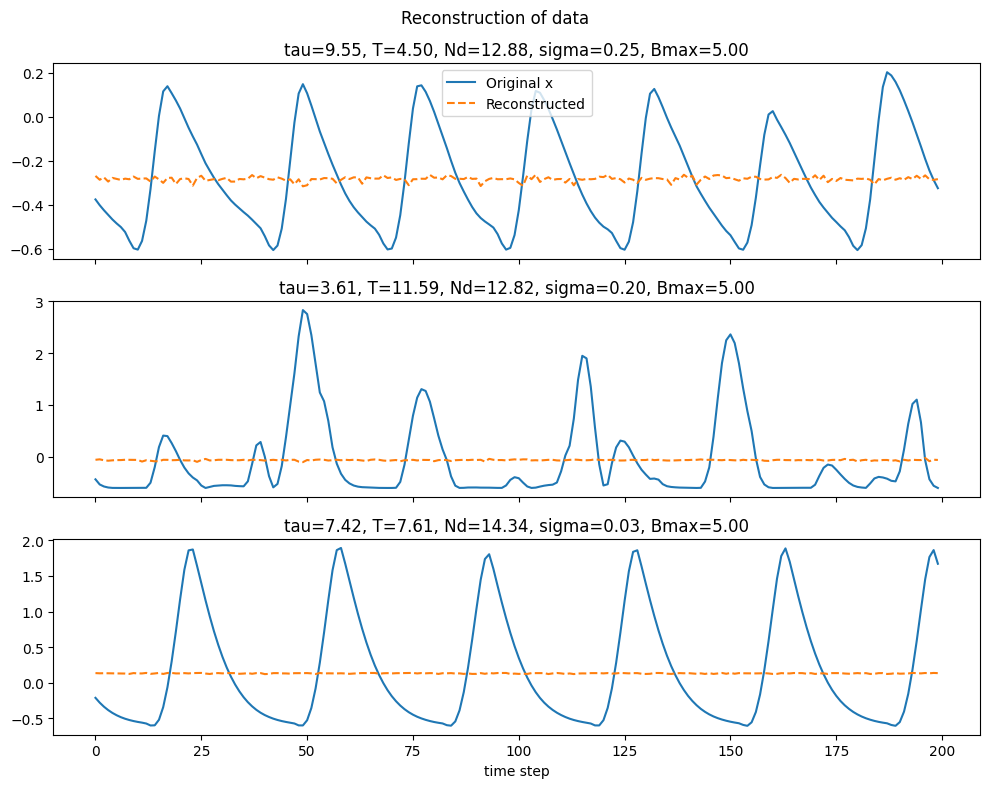

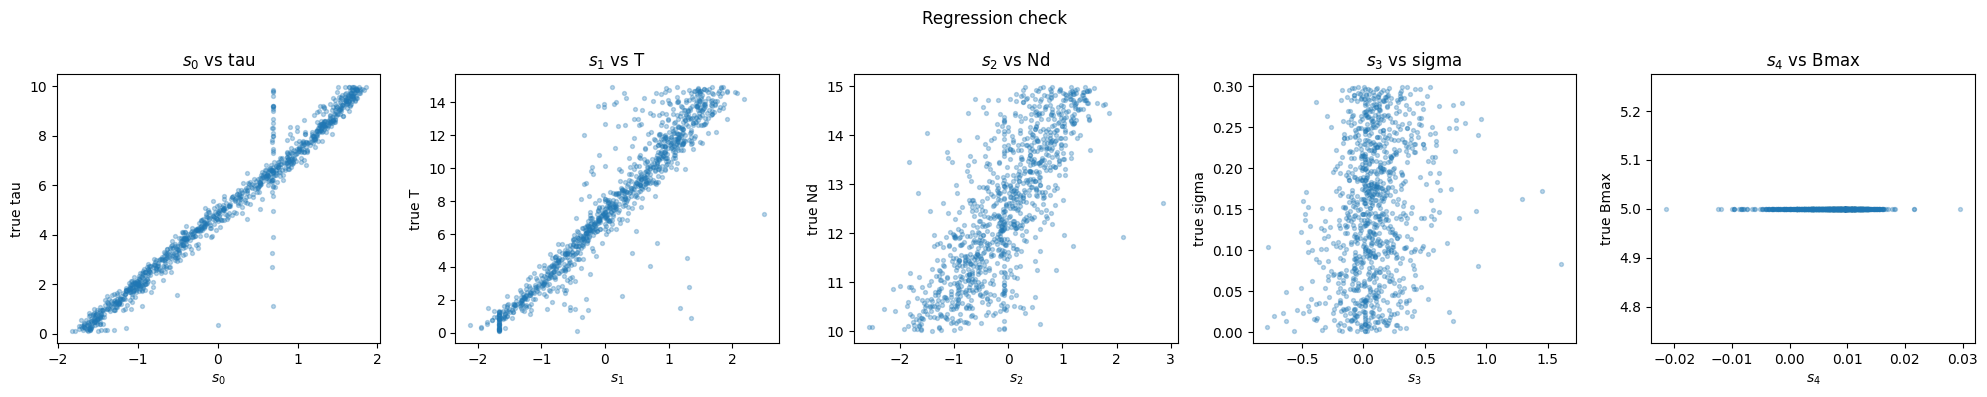

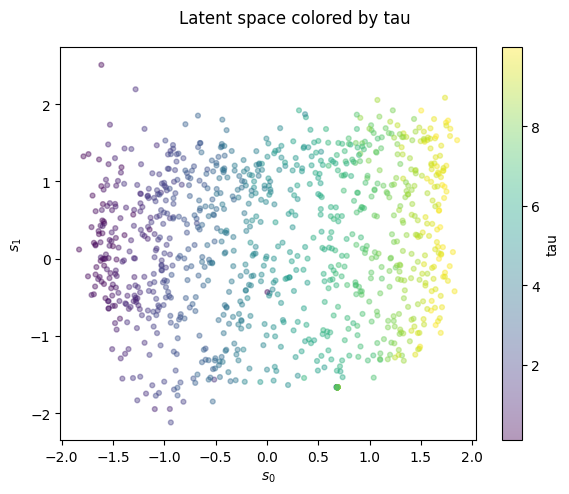

In [33]:
fixed_none = {k: None for k in PARAM_NAMES}

# using MSE loss
res2 = run(fixed_none, n_samples=5000, n_summary=7, epochs=100)

## b) $\chi^2$ loss

In [ ]:
# retrain using chi squared instead of MSE
res2_chi = run(fixed_none, n_samples=5000, n_summary=7, epochs=100, loss="Chi Squared")

## c) BiLSTM Decoder + MSE Loss

In [34]:
res2d = run(fixed_none, n_samples=5000, n_summary=7, epochs=100, BiLSTM=True)


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 5)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.2650
Epoch  40, Loss: 1.2389


KeyboardInterrupt: 


Generating training data...
Generated 10000/10000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(10000, 200)
 Noise=(10000, 200)
 Parameters=(10000, 5)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.2523
Epoch  40, Loss: 1.2138
Epoch  60, Loss: 1.1908
Epoch  80, Loss: 1.1622
Epoch 100, Loss: 1.0976


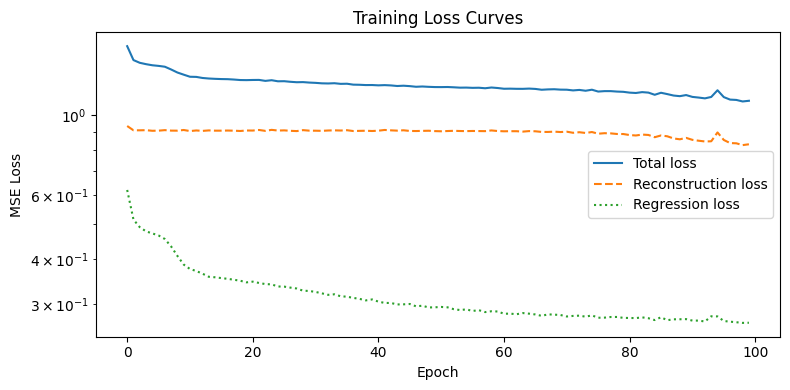


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


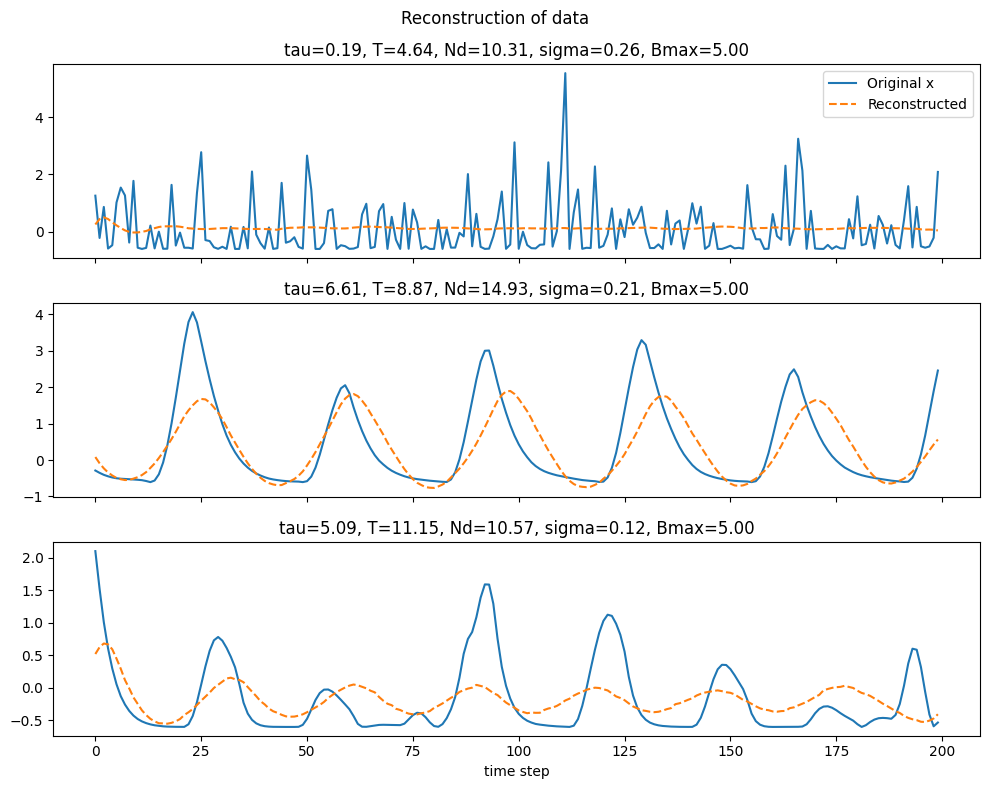

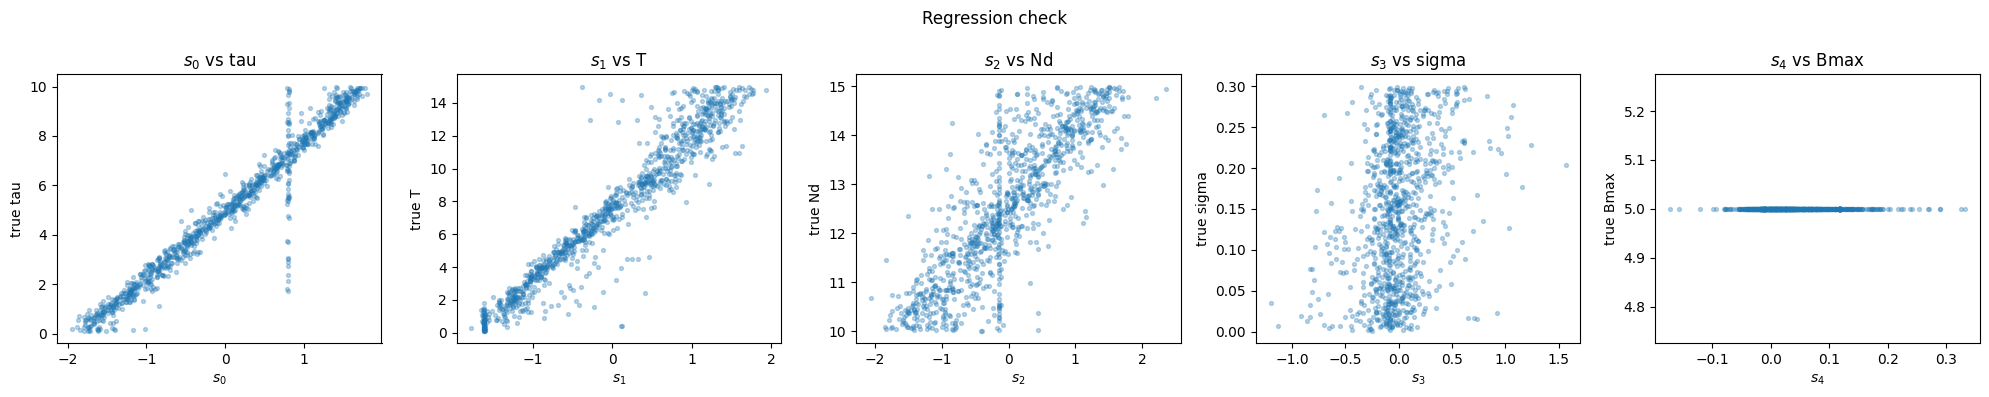

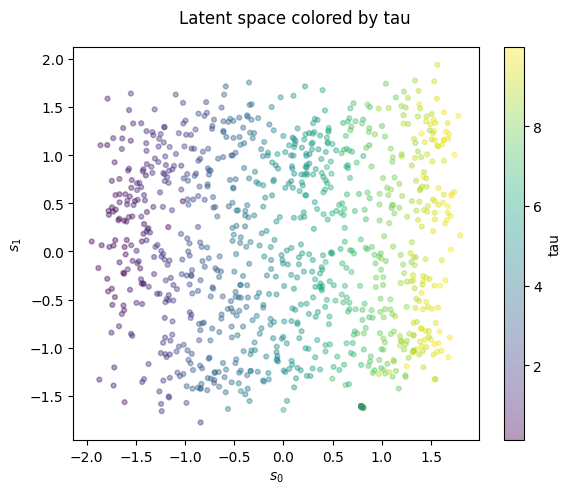

In [35]:
res2d2 = run(fixed_none, n_samples=10000, n_summary=7, epochs=100, BiLSTM=True)

## d) BiLSTM Decoder + $\chi^2$ loss


Generating training data...
Generated 5000/5000 samples

----------------------------------------------------------------------------------------------------

Data shape:
 X shape=(5000, 200)
 Noise=(5000, 200)
 Parameters=(5000, 5)

----------------------------------------------------------------------------------------------------

Training...
Epoch  20, Loss: 1.4656
Epoch  40, Loss: 1.3423
Epoch  60, Loss: 1.3064
Epoch  80, Loss: 1.3332
Epoch 100, Loss: 1.2962


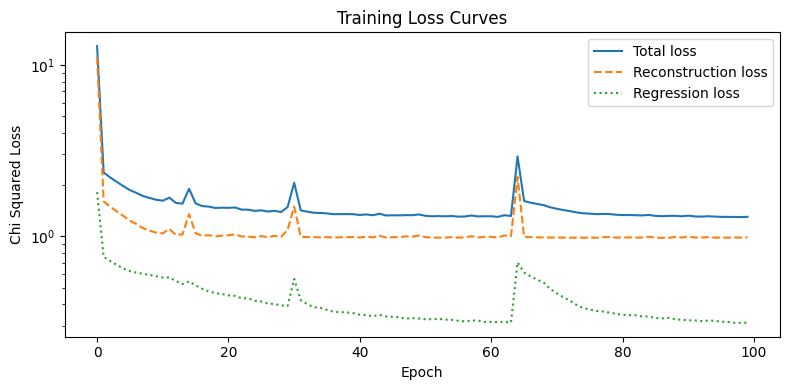


----------------------------------------------------------------------------------------------------

Generating test data...
Generated 1000/1000 samples

----------------------------------------------------------------------------------------------------

Evaluating...


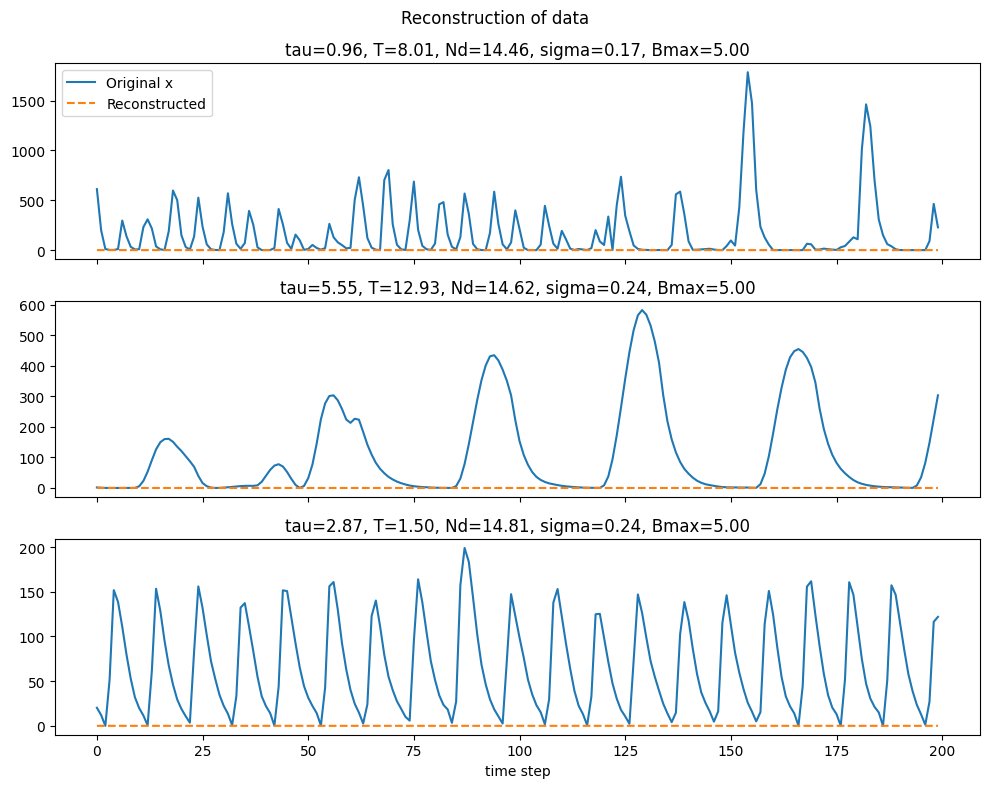

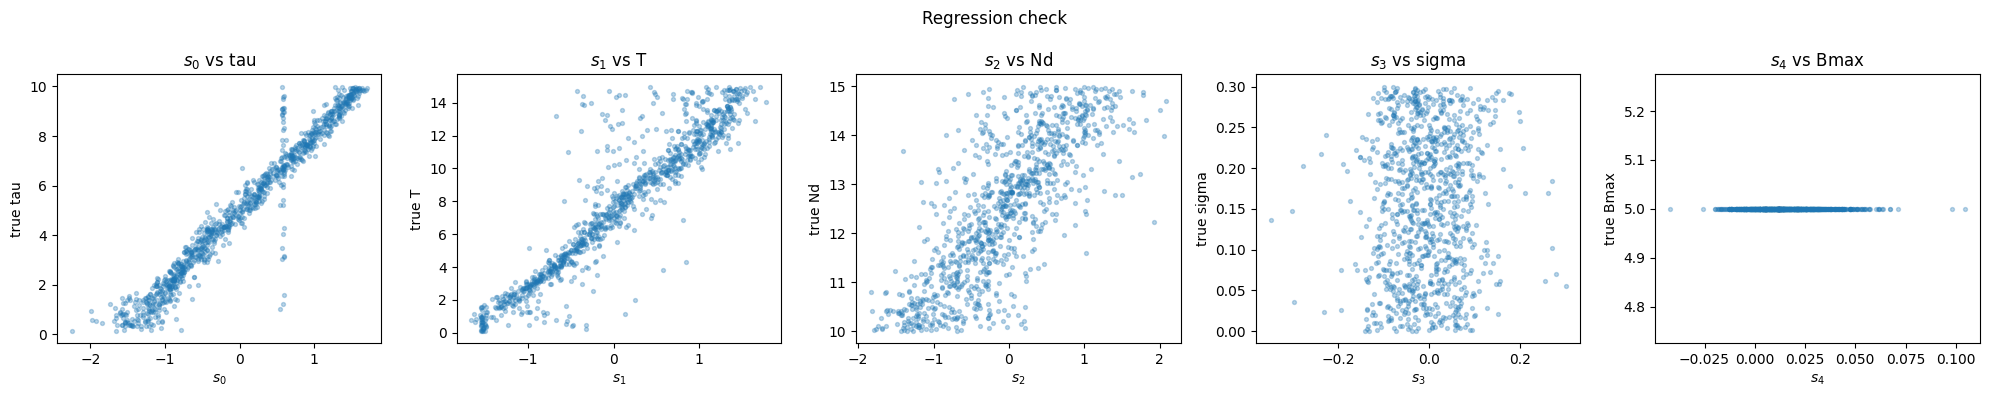

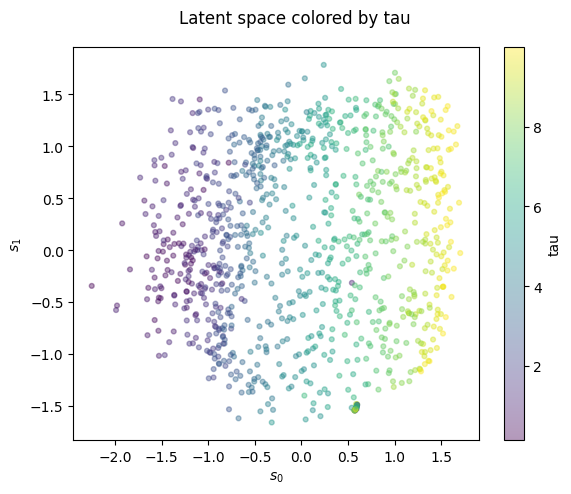

In [36]:
# BiLSTM + Chi Squared
res2e = run(fixed_none, n_samples=5000, epochs=100, n_summary=7, loss="Chi Squared", BiLSTM=True)